In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-18/food_consumption.csv")

data.head()

,country,food_category,consumption,co2_emmission
0,Argentina,Pork,10.51,37.20
1,Argentina,Poultry,38.66,41.53
2,Argentina,Beef,55.48,1712.00
3,Argentina,Lamb & Goat,1.56,54.63
4,Argentina,Fish,4.36,6.96


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1430 non-null   object 
 1   food_category  1430 non-null   object 
 2   consumption    1430 non-null   float64
 3   co2_emmission  1430 non-null   float64
dtypes: float64(2), object(2)
memory usage: 44.8+ KB


#### The average C02 emission per person by food category among five countries (Kenya, Uganda, Tanzania, Rwanda and Ethiopia) located in East Africa.

In [ ]:
# first we select only rows where the countries are kenya, uganda, tanzania, rwanda, ethiopia

ea_data = data[data['country'].isin(['Kenya', 'Uganda', 'Tanzania', 'Rwanda', 'Ethiopia'])]

,country,food_category,consumption,co2_emmission,food_group
902,Kenya,Pork,0.29,1.03,animal
903,Kenya,Poultry,0.47,0.50,animal
904,Kenya,Beef,9.54,294.38,animal
905,Kenya,Lamb & Goat,1.86,65.14,animal
906,Kenya,Fish,4.27,6.82,animal


In [41]:
# then we use those rows for the analysis

avg_co2 = ea_data.groupby('food_category')['co2_emmission'].mean().reset_index()[['food_category', 'co2_emmission']].sort_values(by='co2_emmission', ascending=True)
avg_co2


,food_category,co2_emmission
9,Soybeans,0.236
1,Eggs,0.718
7,Poultry,1.250
6,Pork,3.370
10,Wheat and Wheat Products,3.940
5,Nuts inc. Peanut Butter,4.650
2,Fish,8.428
8,Rice,12.680
3,Lamb & Goat,55.262
4,Milk - inc. cheese,63.754


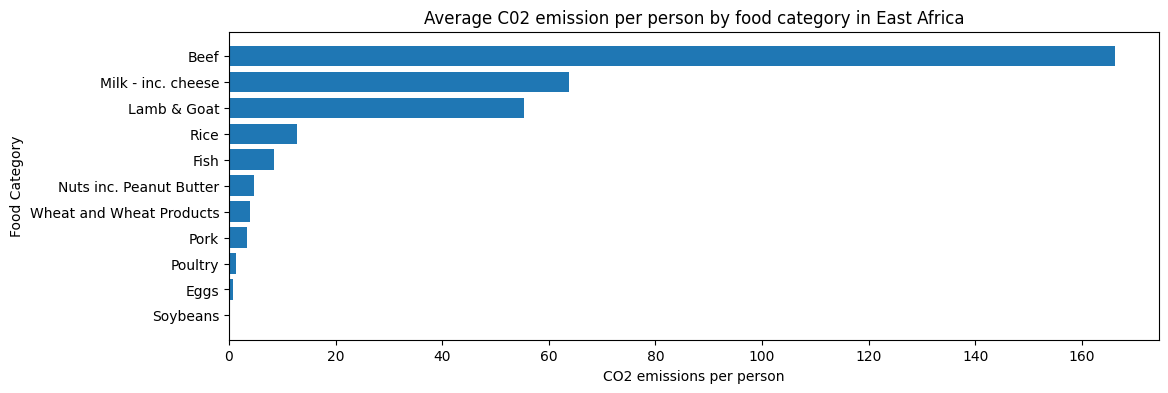

In [42]:
plt.figure(figsize=(12,4))

plt.barh(avg_co2['food_category'], avg_co2['co2_emmission'])
plt.ylabel('Food Category')
plt.xlabel('CO2 emissions per person')
plt.title('Average C02 emission per person by food category in East Africa')

plt.show()

#### Highlight the marked difference between consumption and emissions in certain food product of your choice

In [ ]:
soybean_data = data[data['food_category'] == 'Soybeans']
soybean_data.head()

,country,food_category,consumption,co2_emmission,food_group
9,Argentina,Soybeans,0.00,0.00,plant
20,Australia,Soybeans,0.19,0.09,plant
31,Albania,Soybeans,0.00,0.00,plant
42,Iceland,Soybeans,0.11,0.05,plant
53,New Zealand,Soybeans,0.44,0.20,plant


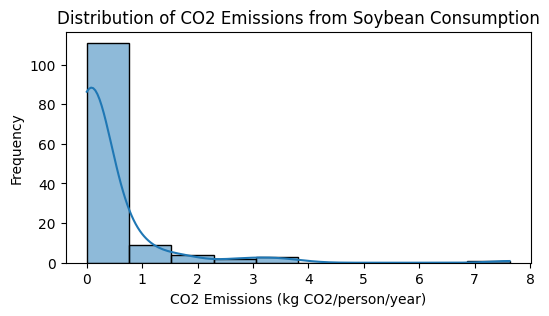

In [83]:
plt.figure(figsize=(6,3))
sns.histplot(data=soybean_data, x='co2_emmission', bins=10, kde=True)
plt.title("Distribution of CO2 Emissions from Soybean Consumption")
plt.xlabel("CO2 Emissions (kg CO2/person/year)")
plt.ylabel("Frequency")
plt.show()

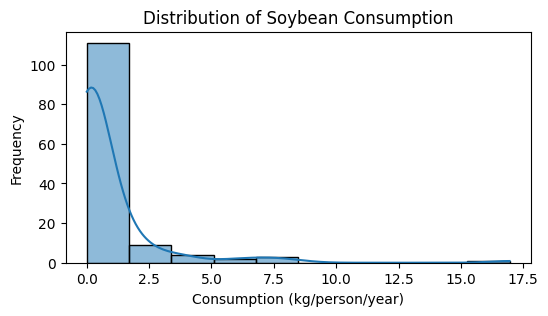

In [84]:
plt.figure(figsize=(6,3))
sns.histplot(data=soybean_data, x='consumption', bins=10, kde=True)
plt.title("Distribution of Soybean Consumption")
plt.xlabel("Consumption (kg/person/year)")
plt.ylabel("Frequency")
plt.show()

#### The food consumption of animal and non-animal products and the impact on carbon footprint.

In [ ]:
data['food_group'] = np.where(data['food_category'].isin(['Beef', 'Milk - inc. cheese', 'Lamb & Goat', 'Pork', 'Fish', 'Poultry', 'Eggs']), 'animal', 'plant')
avg_co2_grouped = data.groupby('food_group')['co2_emmission'].mean().reset_index()
avg_co2_grouped

,food_group,co2_emmission
0,animal,108.468220
1,plant,14.736596


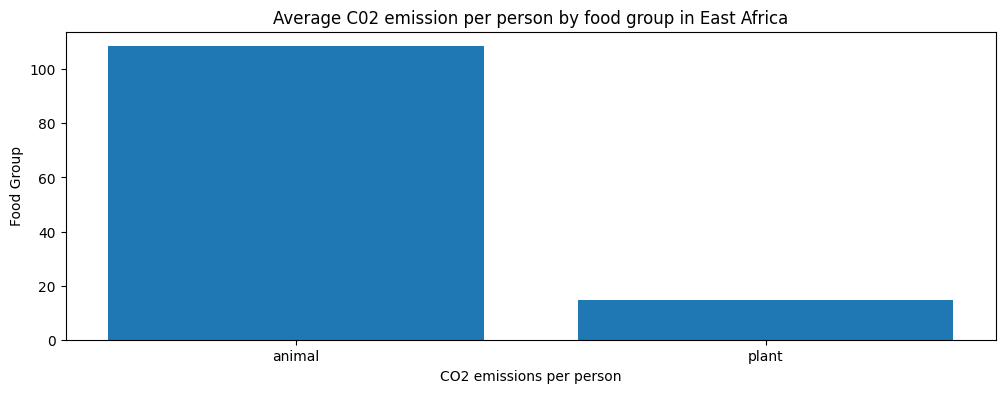

In [38]:
plt.figure(figsize=(12,4))

plt.bar(avg_co2_grouped['food_group'], avg_co2_grouped['co2_emmission'])
plt.ylabel('Food Group')
plt.xlabel('CO2 emissions per person')
plt.title('Average C02 emission per person by food group in East Africa')

plt.show()

#### Beef's contribution to CO2 emissions (kg/person/year)

In [77]:
beef_data = data[data['food_category'] == 'Beef']
beef_data.head()

,country,food_category,consumption,co2_emmission,food_group
2,Argentina,Beef,55.48,1712.00,animal
13,Australia,Beef,33.86,1044.85,animal
24,Albania,Beef,22.50,694.30,animal
35,Iceland,Beef,13.36,412.26,animal
46,New Zealand,Beef,22.49,693.99,animal


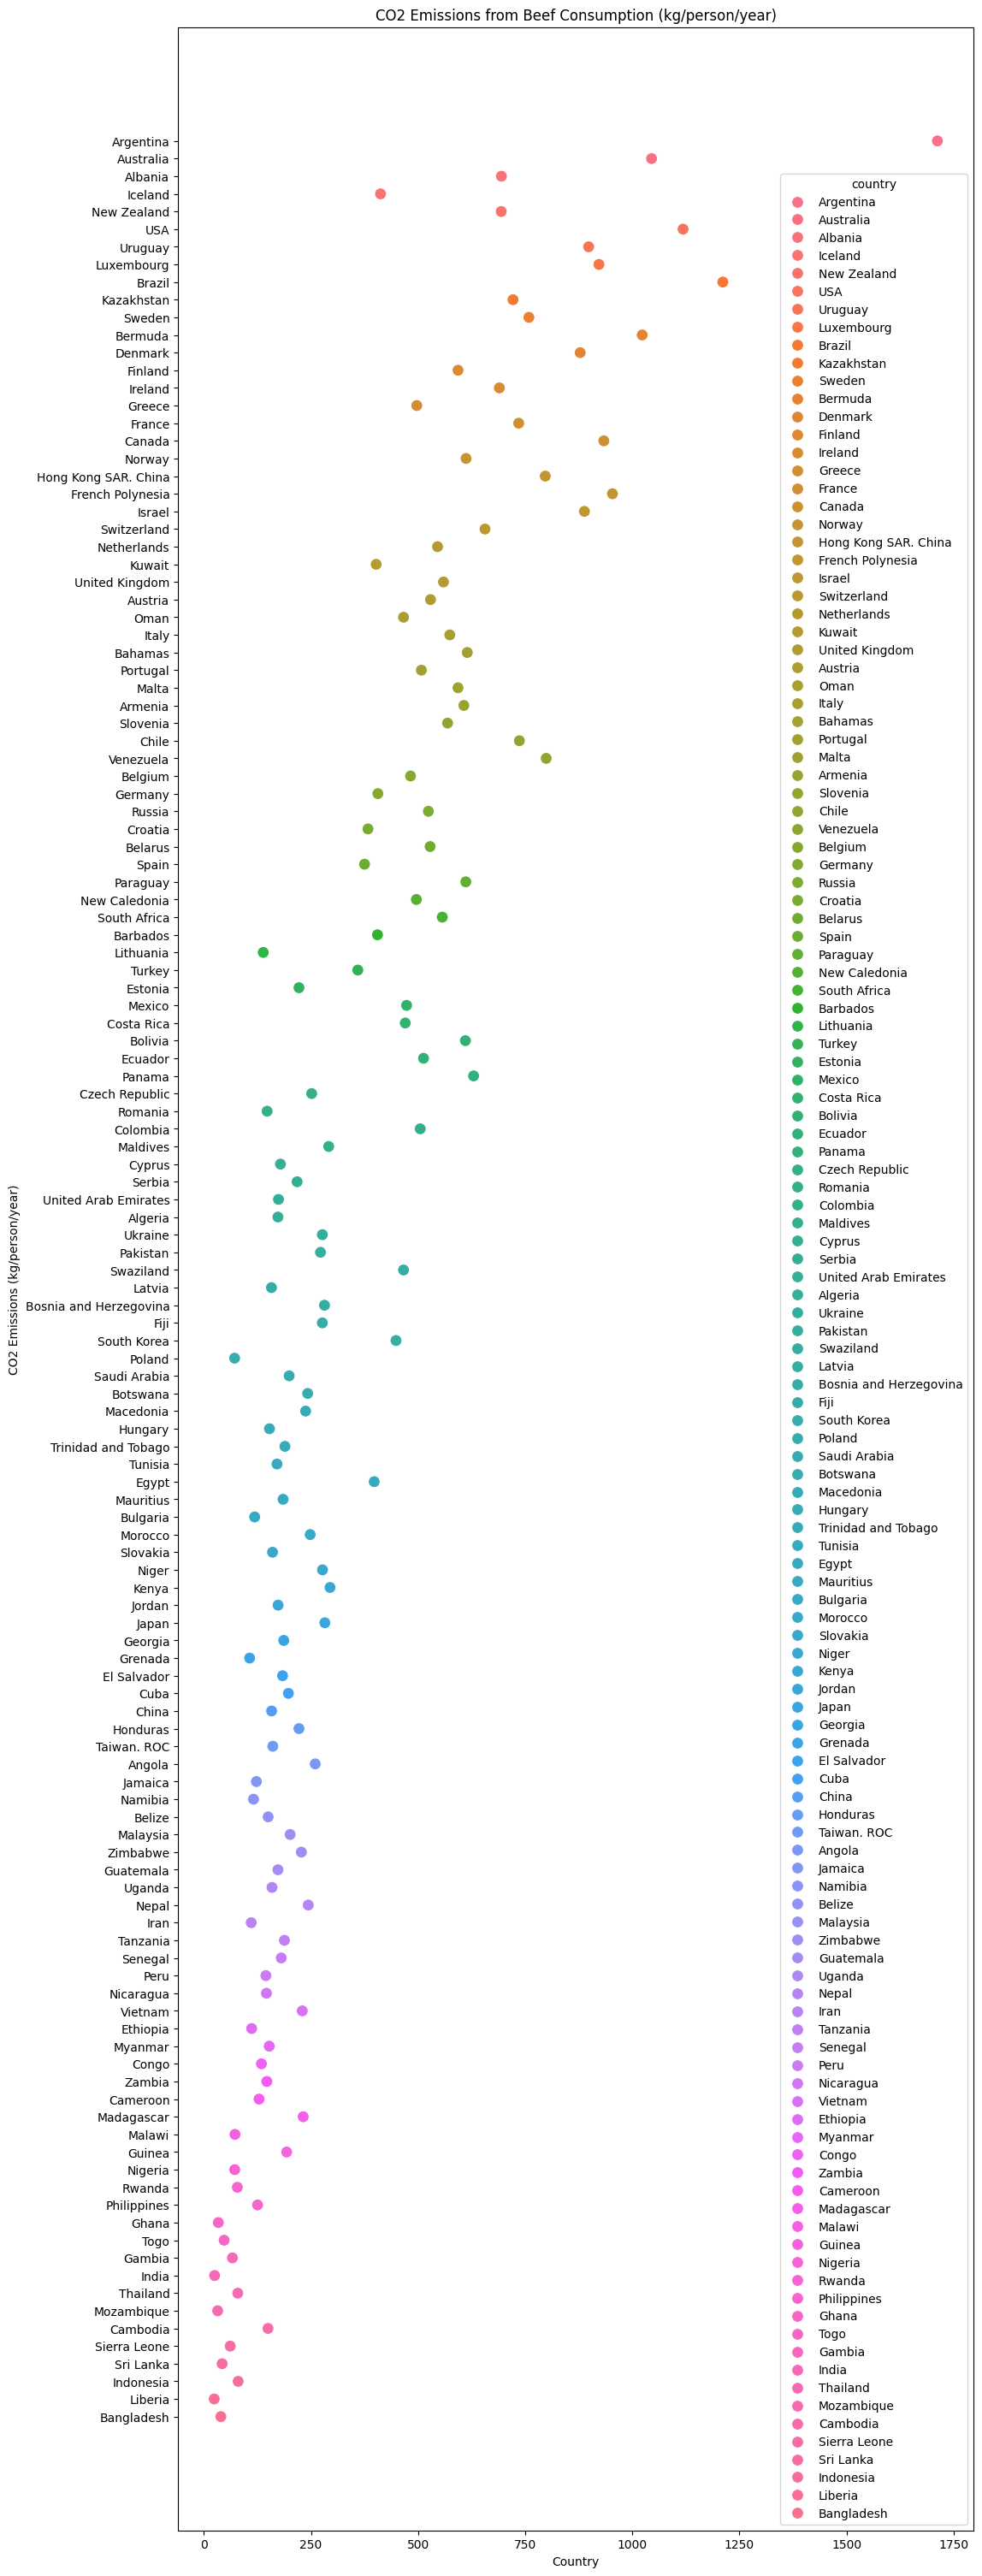

In [ ]:
plt.figure(figsize=(12,38))
sns.scatterplot(data=beef_data, y='country', x='co2_emmission', hue='country', s=100)
plt.title("CO2 Emissions from Beef Consumption (kg/person/year)")
plt.xlabel("Country")
plt.ylabel("CO2 Emissions (kg/person/year)")

plt.show()

#### A box plot and interpretation of the CO2 contributions of food levels.

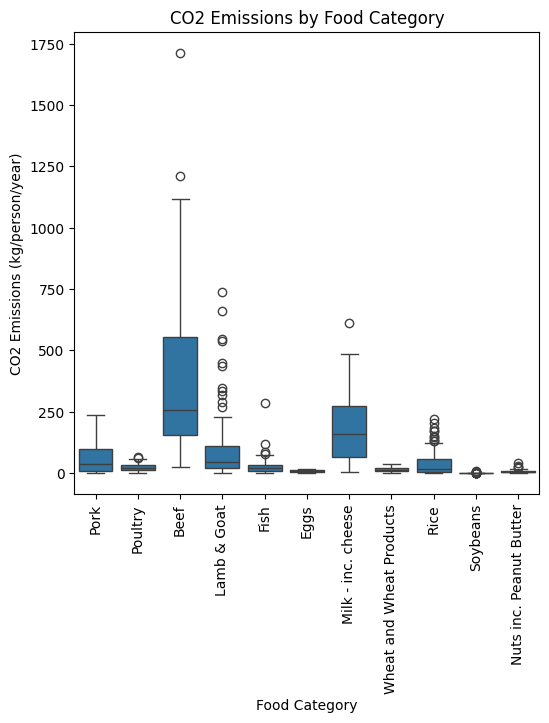

In [65]:
plt.figure(figsize=(6,6))

sns.boxplot(data=data, x='food_category', y='co2_emmission')
plt.xticks(rotation=90)
plt.title("CO2 Emissions by Food Category")
plt.xlabel("Food Category")
plt.ylabel("CO2 Emissions (kg/person/year)")

plt.show()

As expected, animal products have both the largest interquartile ranges, and the highest values overall e.g. beef, lamb & goat and milk products

#### Top 10 Countries with highest emissions.

In [72]:
top10_emissions = data.groupby('country')['co2_emmission'].mean().reset_index().sort_values(by='co2_emmission', ascending=False).head(10)

top10_emissions

,country,co2_emmission
3,Argentina,197.490909
5,Australia,176.241818
0,Albania,161.622727
84,New Zealand,159.177273
52,Iceland,157.396364
120,USA,156.260000
125,Uruguay,148.628182
17,Brazil,146.975455
68,Luxembourg,145.310000
62,Kazakhstan,143.189091


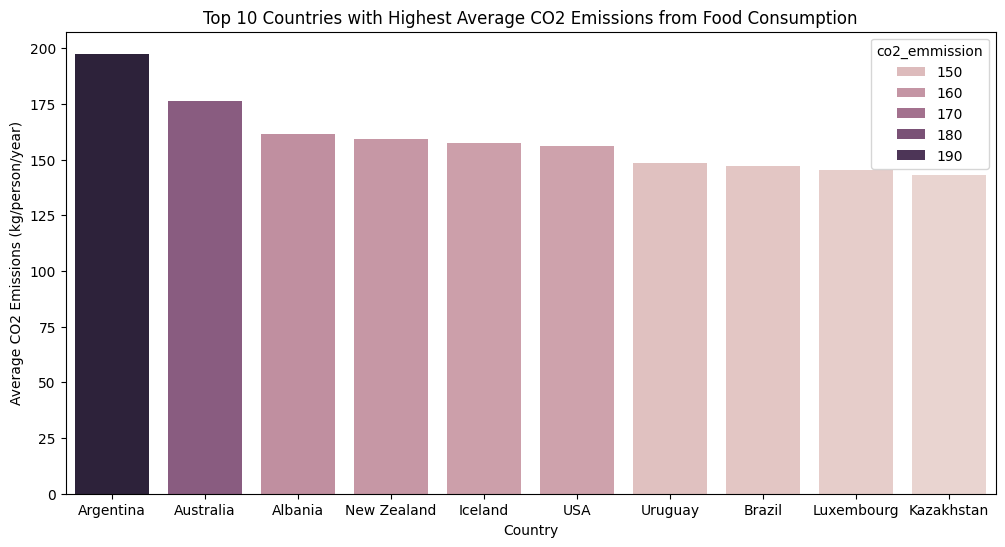

In [73]:
plt.figure(figsize=(12,6))

sns.barplot(data=top10_emissions, x='country', y='co2_emmission', hue='co2_emmission')
plt.title("Top 10 Countries with Highest Average CO2 Emissions from Food Consumption")
plt.xlabel("Country")
plt.ylabel("Average CO2 Emissions (kg/person/year)")

plt.show()

### Use all your data to write a 500 words minimum of insights and the story behind your exploration.

After analyzing the food consumption data i.e. the different food categories and their associated carbon footprints, several insights might be drawn regarding the environmental impact of people's dietary choices. However, given the low number of features, one can only draw surface-level corelations rather than full-blown conclusions.
1. East African Focus: By isolating data from East African countries (Kenya, Uganda, Tanzania, Rwanda, Ethiopia), we observe that animal-based products like beef and dairy tend to have higher emissions compared to plant-based foods. This matches the gloabl averages shown in 'Overall Emission Trends' below, but we cannot say that this is because of the same reasons. For example, a number of communities in East Africa are pre-dominantly pastoralists, subsisting on mainly animal products from their flock. This is in contrast to global north countries, where people might have wider choice when it coems to determining what to eat.
2. Food Category Emissions: The analysis reveals a clear hierarchy in CO2 emissions based on food categories. Animal products, particularly beef, are among the highest contributors to carbon emissions. In contrast, plant-based foods such as fruits, vegetables, and grains exhibit lower emissions. This finding aligns with global research indicating that livestock farming is a major driver of greenhouse gas emissions.
3. Food Group Comparison: When categorizing foods into animal and plant groups, the disparity in emissions becomes even more pronounced. Animal-based foods consistently show higher average CO2 emissions compared to plant-based foods. This suggests that promoting plant-based diets could be a viable strategy for reducing overall carbon footprints.
4. Country-Specific Insights: The scatter plot of beef consumption emissions across countries highlights significant variability. Some countries exhibit notably higher emissions from beef consumption, indicating differing dietary patterns and agricultural practices. This variability suggests that targeted interventions could be more effective if tailored to specific national contexts.
5. Overall Emission Trends: The box plot visualization of CO2 emissions by food category further emphasizes the wide range of emissions associated with different foods. The presence of outliers in certain categories indicates that while average emissions may be moderate, specific instances of high consumption can lead to substantial environmental impacts.
6. Top Emitting Countries: The identification of the top 10 countries with the highest average CO2 emissions from food consumption provides a clear target for policy interventions. However, this assumes that the emissions from these food products comes from consuming them. This might not be the case as some of the countries in the top 10 (Argentina, Brazil), although known for their large cattle farms, rely on these products for export. Wheras they may be emitting CO2 from the 'production', they might not be direct beneficiaries of the 'conumption'

In conclusion, this analysis shows the significant role that dietary choices play in shaping carbon footprints. By shifting towards country-specific strategies rather than broad generalisations of consumption vs emission, it is possible to make meaningful progress in reducing the environmental impact of food consumption globally.